# Ensemble Methods

---

## Overview

**Ensemble methods** combine multiple base learners to produce a more accurate model.

### Bagging (Bootstrap Aggregating)
Train $T$ trees on independent **bootstrap samples** of the data; aggregate by majority vote:
$$\hat{y} = \text{mode}\{h_1(\mathbf{x}), h_2(\mathbf{x}), \dots, h_T(\mathbf{x})\}$$

**Random Forest** adds random feature subsets at each split, reducing correlation between trees.

### Boosting (Gradient Boosting)
Train sequentially; each tree fits the **residuals** of the previous ensemble:
$$F_0(x) = \bar{y}, \quad F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$
where $h_m$ is a shallow tree fit to $r_i = y_i - F_{m-1}(x_i)$ and $\eta$ is the learning rate.

---

**Datasets:** `heart.csv` (classification), `bodyfat.csv` (regression); fall back to sklearn datasets.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

from rice_ml.supervised_learning import (
    RandomForestClassifier, RandomForestRegressor,
    BaggingClassifier, GradientBoostingRegressor,
    DecisionTreeClassifier, DecisionTreeRegressor,
)
from rice_ml.preprocess import StandardScaler, train_test_split
from rice_ml.metrics import accuracy_score, mse, r2_score


In [2]:
# Classification dataset
try:
    df = pd.read_csv('../../../data/heart.csv')
    X_cls = df.drop(columns=['target']).values.astype(float)
    y_cls = df['target'].values
    print(f'Loaded heart dataset: {X_cls.shape}')
except FileNotFoundError:
    from sklearn.datasets import load_breast_cancer
    data = load_breast_cancer()
    X_cls, y_cls = data.data, data.target
    print('CSV not found. using breast cancer dataset')

scaler_cls = StandardScaler()
X_cls_s = scaler_cls.fit_transform(X_cls)
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_cls_s, y_cls, test_size=0.2, random_state=42)


Loaded heart dataset: (1025, 13)


## Random Forest Classifier


In [3]:
rf = RandomForestClassifier(n_estimators=50, max_depth=5)
rf.fit(X_tr_c, y_tr_c)
print(f'Random Forest Test Accuracy: {accuracy_score(y_te_c, rf.predict(X_te_c)):.4f}')


Random Forest Test Accuracy: 0.8732


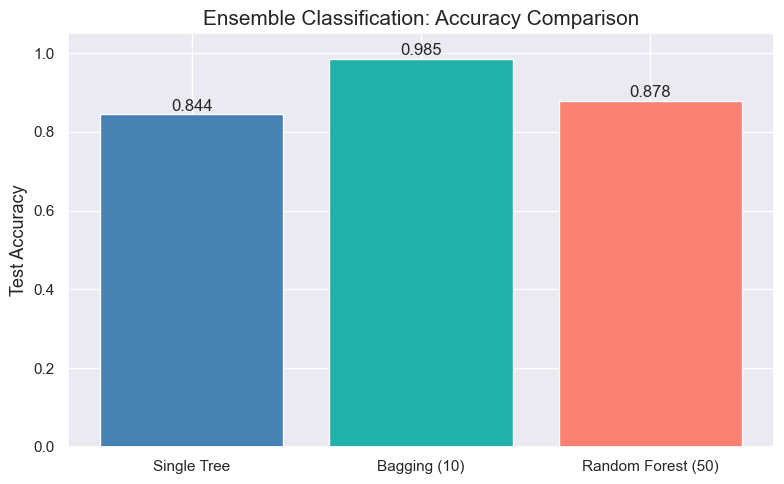

In [4]:
# Compare classification methods
methods_cls = ['Single Tree', 'Bagging (10)', 'Random Forest (50)']
models_cls = [
    DecisionTreeClassifier(max_depth=5),
    BaggingClassifier(n_estimators=10),
    RandomForestClassifier(n_estimators=50, max_depth=5),
]

accs = []
for model in models_cls:
    model.fit(X_tr_c, y_tr_c)
    accs.append(accuracy_score(y_te_c, model.predict(X_te_c)))

plt.figure(figsize=(8, 5))
bars = plt.bar(methods_cls, accs, color=['steelblue', 'lightseagreen', 'salmon'])
plt.ylim(0, 1.05)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=13)
plt.title('Ensemble Classification: Accuracy Comparison', fontsize=15)
plt.tight_layout()
plt.show()


## Gradient Boosting Regressor


In [5]:
# Regression dataset
try:
    df_fat = pd.read_csv('../../../data/bodyfat.csv')
    target_col = 'BodyFat' if 'BodyFat' in df_fat.columns else df_fat.columns[-1]
    X_reg = df_fat.drop(columns=[target_col]).values.astype(float)
    y_reg = df_fat[target_col].values.astype(float)
    print(f'Loaded body fat dataset: {X_reg.shape}')
except FileNotFoundError:
    from sklearn.datasets import make_regression
    X_reg, y_reg = make_regression(n_samples=300, n_features=8, noise=5, random_state=1)
    print('CSV not found. using synthetic regression data')

scaler_reg = StandardScaler()
X_reg_s = scaler_reg.fit_transform(X_reg)
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg_s, y_reg, test_size=0.2, random_state=42)


Loaded body fat dataset: (252, 14)


In [6]:
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)
gbr.fit(X_tr_r, y_tr_r)
print(f'Gradient Boosting R²:       {r2_score(y_te_r, gbr.predict(X_te_r)):.4f}')
print(f'Gradient Boosting MSE:      {mse(y_te_r, gbr.predict(X_te_r)):.4f}')
print(f'Number of trees:            {len(gbr.estimators_)}')


Gradient Boosting R²:       0.9982
Gradient Boosting MSE:      0.0755
Number of trees:            100


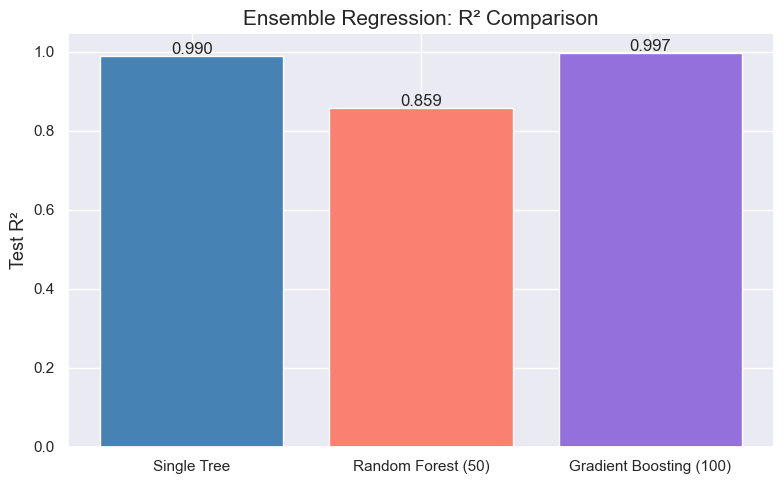

In [7]:
# Compare regression methods
methods_reg = ['Single Tree', 'Random Forest (50)', 'Gradient Boosting (100)']
r2s = []
for model in [
    DecisionTreeRegressor(max_depth=5),
    RandomForestRegressor(n_estimators=50, max_depth=5),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3),
]:
    model.fit(X_tr_r, y_tr_r)
    r2s.append(r2_score(y_te_r, model.predict(X_te_r)))

plt.figure(figsize=(8, 5))
bars = plt.bar(methods_reg, r2s, color=['steelblue', 'salmon', 'mediumpurple'])
for bar, r2 in zip(bars, r2s):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{r2:.3f}', ha='center', fontsize=12)
plt.ylabel('Test R²', fontsize=13)
plt.title('Ensemble Regression: R² Comparison', fontsize=15)
plt.tight_layout()
plt.show()


## Interpretation

- **Bagging** reduces variance by averaging over many uncorrelated trees. effective when single trees overfit.
- **Random Forest** improves on bagging by also randomizing feature selection at each split, further decorrelating trees.
- **Gradient Boosting** reduces bias by fitting each tree to the residuals of the current ensemble. powerful for regression tasks when data has complex patterns.
